# ESCUELA COLOMBIANA DE INGENIERÍA
# PRINCIPIOS Y TECNOLOGÍAS IA 2026-1
## ARBOLES DE DECISIÓN
## LABORATORIO 1/4

**OBJETIVOS**

Desarrollar competencias básicas para:
1. Modelar y resolver problemas usando árboles de decisión
2. Implementar árboles de decisión
3. Apropiar un framework para árboles de decisión (*scikit-learn*)
4. Conocer una librería para procesamiento de datos simbólicos (*python pandas DataFrame*)

**ENTREGABLE**


*Reglas para el envío de los entregables*:

* **Forma de envío:**
Este laboratorio se debe enviar únicamente a través de la plataforma Moodle en la actividad definida. Se tendrán dos entregas: inicial y final.

* **Formato de los archivos:**
Incluyan en un archivo *.zip* los archivos correspondientes al laboratorio.

* **Nomenclatura para nombrar los archivos:**
El archivo deberá ser renombrado, “DT-lab-” seguido por los usuarios institucionales de los autores ordenados alfabéticamente (por ejemplo, se debe adicionar pedroperez al nombre del archivo, si el correo electrónico de Pedro Pérez es pedro.perez@mail.escuelaing.edu.co)




# **PARTE I. IMPLEMENTACIÓN DE ÁRBOLES DE DECISIÓN**
Para este apartado se van a implementar un árbol de decisión, en este caso usando como medida la entropia.

*La idea de los árboles de decisión fue desarrollada paulatinamiente. El pionero más reconocido es Ross Quinlan, quien propuso en 1986 el algoritmo ID3 (Iterative Dichotomiser 3) en el artículo [Induction of decision trees](https://link.springer.com/article/10.1007/BF00116251). Este algoritmo marcó un hito en la construcción automática de árboles de decisión a partir de datos.*

## I.A. IMPLEMENTACIÓN DE UN ÁRBOL DE DECISIÓN

Implementar un árbol de decisión; calculando una salida $\check{Y} (Yp)$ para unas entradas $X$.

**Propiedades:**

*   Tarea: **Clasificación binaria**
*   Características: **Categóricas**
*   Criterio de selección: **Ganancia de información**
*   Métrica para evaluación : **F1 SCORE**

<div>
<img src="https://cdn.analyticsvidhya.com/wp-content/uploads/2020/09/Precision-vs-Recall-in-Machine-Learning.webp" width="350"/>
</div>

> **Formulas**

*   Impureza : **Entropía: H**

*   Ganancia de información: **IG(D,A)**

*   Impureza de Arbol: **Impurity(V\*)**







## Paso 1. Criterios de selección de atributos
Las impurezas en árboles de decision miden cuán homogéneas o heterogéneas son las clases dentro de un conjunto de datos ***en un nodo del árbol***. La métrica de impureza determina cómo dividir los datos en cada nodo.
Los principales métodos de evaluación de impureza son: **entropía** e **indice gini**.

*Incluyan las formulas de los dos criterios de selección y comparelos considerando criterios como sensibilidad al desbalance de clases y eficiencia computacional*

---
**Entropía**

Mide el desorden de las clases en un conjunto $S$.

$$
H(S) = -\sum_{i=1}^{|C|} p_i \log_2 (p_i)
$$

- $p_i$: proporción de ejemplos de la clase $i$ en el conjunto $S$.  
- $|C|$: número total de clases.  
- Rango (clasificación binaria): $0 \le H(S) \le 1$.  
- $H(S)=0$: conjunto puro (todas las muestras son de una sola clase).  
- $H(S)=1$: máxima mezcla (50\%-50\%).  

---

**Gini**

Mide la probabilidad de clasificar mal un ejemplo si se etiqueta al azar según la distribución del conjunto.

$$
Gini(S) = 1 - \sum_{i=1}^{|C|} p_i^2
$$

donde:

- $p_i$ es la proporción de ejemplos de la clase $i$ en el conjunto $S$.
- $|C|$ es el número total de clases.

En el caso binario:

$$
Gini(S) = 2p(1-p)
$$

donde $p$ es la probabilidad de la clase positiva.

Rango (clasificación binaria):

$$
0 \le Gini(S) \le 0.5
$$

- $Gini(S)=0$: conjunto puro.
- El valor máximo ocurre en $p=0.5$.


---
**Comparación**

- **Sensibilidad al desbalance**:
  - Ambos se afectan por clases desbalanceadas.
  - **Entropía** suele ser más sensible a cambios pequeños en probabilidades (incluyendo clase minoritaria), por usar logaritmo.
  - **Gini** tiende a favorecer un poco más la clase mayoritaria si no se compensa el desbalance.

- **Eficiencia computacional**:
  - **Gini** es más barato ya que no usa logaritmos.
  - **Entropía** es un poco más costosa, pero suele dar divisiones muy similares a Gini.


## Paso 2. Ganancia de una característica e impureza del árbol
Los otros dos conceptos de fundamentan los árboles de decisión son la **ganancia de información** y la **impureza de un arbol**.

*Expliquen su proposito y la fórmula correspondiente, detallandola.*
 
---

**Ganancia de Información:**

La ganancia de información mide cuánta información nos proporciona una característica sobre la clasificación. Es la reducción en la entropía (o impureza) que se obtiene al dividir los datos según una característica específica. Se utiliza para decidir qué característica usar en cada nodo del árbol, seleccionando aquella que maximice la ganancia.

**Fórmula:**

$$\text{Ganancia}(S, A) = \text{Entropía}(S) - \sum_{v \in \text{Valores}(A)} \frac{|S_v|}{|S|} \cdot \text{Entropía}(S_v)$$

Donde:
- $S$ es el conjunto de datos actual
- $A$ es la característica (atributo) que estamos evaluando
- $\text{Valores}(A)$ son los posibles valores de la característica $A$
- $S_v$ es el subconjunto de $S$ donde la característica $A$ tiene el valor $v$
- $|S|$ es el tamaño del conjunto $S$

---
**Impureza del Árbol:**

La impureza es una medida de cuán mezcladas están las clases en un conjunto de datos. Un nodo es "puro" si todos sus ejemplos pertenecen a la misma clase, e "impuro" si contiene ejemplos de múltiples clases. El objetivo del árbol de decisión es minimizar la impureza en los nodos hoja.

**Fórmulas de Impureza:**

1. **Entropía**:
   $$\text{Entropía}(S) = -\sum_{i=1}^{|c|} p_i \log_2(p_i)$$
   
2. **Índice de Gini**:
   $$\text{Gini}(S) = 1 - \sum_{i=1}^{|c|} p_i^2$$


**Interpretación:**
- Una entropía de 0 indica pureza total (todas las instancias pertenecen a una sola clase)
- Una entropía máxima indica máxima impureza (las clases están uniformemente distribuidas)


## Paso 3. Implementación del código base para un árbol de decisión

### Librería necesaria

In [1]:
import pandas as pd
from abc import ABC, abstractmethod

### Funciones base: métrica y criterio

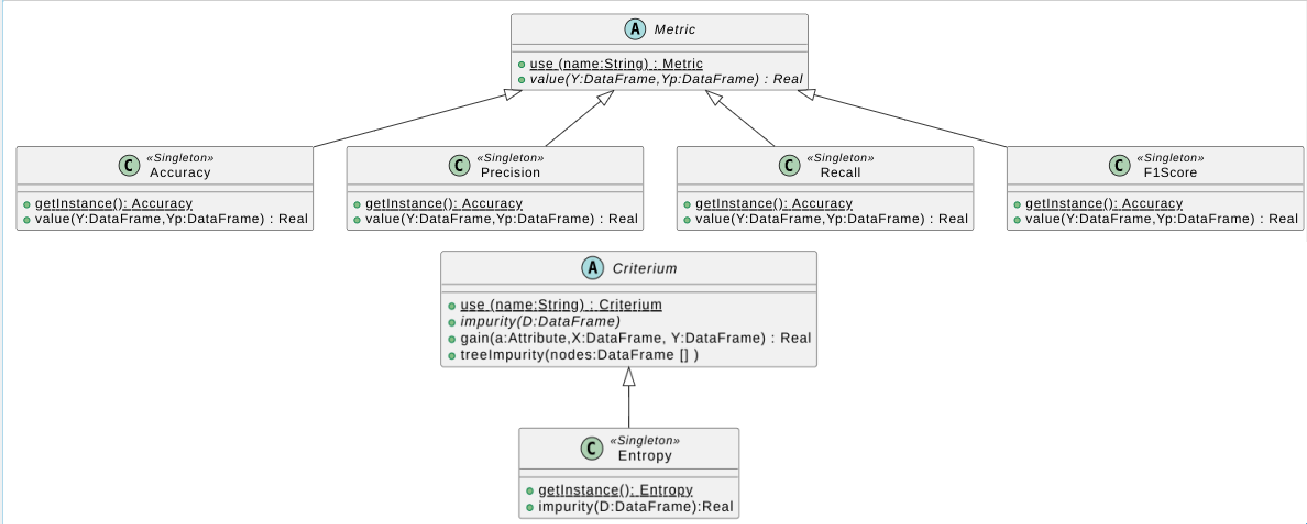

### Métrica

In [29]:
class Metric(ABC):
  """ Abstracta: define entradas, salidas y el comportamiento inicial de los métodos
  clave para cualquier metrica.
  Representa una metrica de desempeño P para evaluar una tarea T.
  """
  @classmethod
  def use(cls, name: str):
    """ Factory: obtiene una instancia (Singleton) de la métrica por nombre.
    Args:
      name : nombre de la métrica ('accuracy', 'precision', 'recall', 'f1' / 'f1score')
    Returns:
      instancia de la métrica solicitada
    Raises:
      ValueError si el nombre no corresponde a ninguna métrica soportada
    """
    key = name.strip().lower()
    if key == "accuracy":
      return Accuracy.getInstance()
    if key == "precision":
      return Precision.getInstance()
    if key == "recall":
      return Recall.getInstance()
    if key in ("f1", "f1score"):
      return F1Score.getInstance()
    raise ValueError(f"Métrica no soportada: {name}")

  @staticmethod
  def _to_series(v) -> pd.Series:
    """ Convierte v (Series, DataFrame de 1 col, o iterable) a pd.Series. """
    if isinstance(v, pd.DataFrame):
      if v.shape[1] != 1:
        raise ValueError("Se esperaba DataFrame de una sola columna")
      v = v.iloc[:, 0]
    elif not isinstance(v, pd.Series):
      v = pd.Series(v)
    return v.reset_index(drop=True)

  @staticmethod
  def _validate(Y, Yp):
    """ Valida y normaliza las entradas Y e Yp a pd.Series alineadas. """
    y = Metric._to_series(Y)
    yp = Metric._to_series(Yp)
    if len(y) != len(yp):
      raise ValueError("Y y Yp deben tener la misma longitud")
    if len(y) == 0:
      raise ValueError("Y y Yp no pueden estar vacíos")
    return y, yp

  @staticmethod
  def _positive_label(y, yp):
    """ Detecta la etiqueta positiva: 1 si existe, de lo contrario el valor máximo. """
    vals = pd.concat([y, yp], ignore_index=True).dropna().unique().tolist()
    if 1 in vals:
      return 1
    return max(vals)

  @abstractmethod
  def value(self, Y: pd.DataFrame, Yp: pd.DataFrame) -> float:
    """ Computa el desempeño P.
    Args:
      Y  : valores de salidas esperadas (etiquetadas)
      Yp : valores de salidas obtenidas
    Return:
      valor del desempeño (float entre 0.0 y 1.0)
    """
    pass


In [30]:
class Accuracy(Metric):
  """ Métrica de exactitud: proporción de predicciones correctas sobre el total.
  Fórmula: (TP + TN) / (TP + TN + FP + FN)
  Implementa Metric usando patrón Singleton.
  """
  _instance = None

  def __new__(cls):
    """ Garantiza que solo existe una instancia (Singleton). """
    if cls._instance is None:
      cls._instance = object.__new__(cls)
    return cls._instance

  @classmethod
  def getInstance(cls):
    """ Retorna la única instancia de Accuracy. """
    return cls()

  def value(self, Y: pd.DataFrame, Yp: pd.DataFrame) -> float:
    """ Calcula la exactitud como la proporción de predicciones correctas.
    Args:
      Y  : valores de salidas esperadas (etiquetadas)
      Yp : valores de salidas obtenidas
    Return:
      Exactitud entre 0.0 y 1.0
    """
    y, yp = Metric._validate(Y, Yp)
    return (y == yp).sum() / len(y)


In [31]:
class Precision(Metric):
  """ Métrica de precisión: de todos los predichos como positivos, cuántos
  realmente lo son.
  Fórmula: TP / (TP + FP)
  Implementa Metric usando patrón Singleton.
  """
  _instance = None

  def __new__(cls):
    """ Garantiza que solo existe una instancia (Singleton). """
    if cls._instance is None:
      cls._instance = object.__new__(cls)
    return cls._instance

  @classmethod
  def getInstance(cls):
    """ Retorna la única instancia de Precision. """
    return cls()

  def value(self, Y: pd.DataFrame, Yp: pd.DataFrame) -> float:
    """ Calcula la precisión: TP / (TP + FP).
    Si no hay predicciones positivas (TP + FP == 0) retorna 0.0.
    Args:
      Y  : valores de salidas esperadas (etiquetadas)
      Yp : valores de salidas obtenidas
    Return:
      Precisión entre 0.0 y 1.0
    """
    y, yp = Metric._validate(Y, Yp)
    pos = Metric._positive_label(y, yp)
    tp = ((y == pos) & (yp == pos)).sum()
    fp = ((y != pos) & (yp == pos)).sum()
    if (tp + fp) == 0:
      return 0.0
    return tp / (tp + fp)


In [32]:
class Recall(Metric):
  """ Métrica de exhaustividad (recall / sensibilidad): de todos los positivos
  reales, cuántos fueron detectados.
  Fórmula: TP / (TP + FN)
  Implementa Metric usando patrón Singleton.
  """
  _instance = None

  def __new__(cls):
    """ Garantiza que solo existe una instancia (Singleton). """
    if cls._instance is None:
      cls._instance = object.__new__(cls)
    return cls._instance

  @classmethod
  def getInstance(cls):
    """ Retorna la única instancia de Recall. """
    return cls()

  def value(self, Y: pd.DataFrame, Yp: pd.DataFrame) -> float:
    """ Calcula la exhaustividad: TP / (TP + FN).
    Si no hay positivos reales (TP + FN == 0) retorna 0.0.
    Args:
      Y  : valores de salidas esperadas (etiquetadas)
      Yp : valores de salidas obtenidas
    Return:
      Exhaustividad entre 0.0 y 1.0
    """
    y, yp = Metric._validate(Y, Yp)
    pos = Metric._positive_label(y, yp)
    tp = ((y == pos) & (yp == pos)).sum()
    fn = ((y == pos) & (yp != pos)).sum()
    if (tp + fn) == 0:
      return 0.0
    return tp / (tp + fn)


In [33]:
class F1Score(Metric):
  """ Métrica F1: media armónica entre Precisión y Exhaustividad.
  Fórmula: 2 * (Precision * Recall) / (Precision + Recall)
  Penaliza los modelos que son buenos solo en una de las dos métricas.
  Implementa Metric usando patrón Singleton.
  """
  _instance = None

  def __new__(cls):
    """ Garantiza que solo existe una instancia (Singleton). """
    if cls._instance is None:
      cls._instance = object.__new__(cls)
    return cls._instance

  @classmethod
  def getInstance(cls):
    """ Retorna la única instancia de F1Score. """
    return cls()

  def value(self, Y: pd.DataFrame, Yp: pd.DataFrame) -> float:
    """ Calcula el F1 Score: 2 * (Precision * Recall) / (Precision + Recall).
    Si Precision + Recall == 0 retorna 0.0 (evita división por cero).
    Args:
      Y  : valores de salidas esperadas (etiquetadas)
      Yp : valores de salidas obtenidas
    Return:
      F1 Score entre 0.0 y 1.0
    """
    p = Precision().value(Y, Yp)
    r = Recall().value(Y, Yp)
    if (p + r) == 0:
      return 0.0
    return 2 * p * r / (p + r)


In [34]:
# Casos de prueba de las métricas
# Y  = etiquetas reales
# Yp = predicciones del modelo
#
# Análisis manual del ejemplo:
#   Y  = [1, 1, 1, 0, 0, 0, 1, 0, 1, 0]
#   Yp = [1, 0, 1, 0, 1, 0, 1, 1, 0, 0]
#
#   TP (Y=1, Yp=1): índices 0, 2, 6        → 3
#   FP (Y=0, Yp=1): índices 4, 7           → 2
#   FN (Y=1, Yp=0): índices 1, 8           → 2
#   TN (Y=0, Yp=0): índices 3, 5, 9        → 3
#
#   Accuracy  = (TP+TN)/(TP+FP+FN+TN) = 6/10 = 0.6000
#   Precision = TP/(TP+FP)            = 3/5  = 0.6000
#   Recall    = TP/(TP+FN)            = 3/5  = 0.6000
#   F1        = 2*(0.6*0.6)/(0.6+0.6)        = 0.6000

Y  = pd.Series([1, 1, 1, 0, 0, 0, 1, 0, 1, 0])
Yp = pd.Series([1, 0, 1, 0, 1, 0, 1, 1, 0, 0])

acc  = Metric.use("accuracy")
prec = Metric.use("precision")
rec  = Metric.use("recall")
f1   = Metric.use("f1")

print(f"Accuracy  : {acc.value(Y, Yp):.4f}")   
print(f"Precision : {prec.value(Y, Yp):.4f}")  
print(f"Recall    : {rec.value(Y, Yp):.4f}")   
print(f"F1 Score  : {f1.value(Y, Yp):.4f}")    


Yp_perf = Y.copy()
print(f"\nCaso perfecto:")
print(f"  Accuracy  : {acc.value(Y, Yp_perf):.4f}")   
print(f"  Precision : {prec.value(Y, Yp_perf):.4f}")  
print(f"  Recall    : {rec.value(Y, Yp_perf):.4f}")   
print(f"  F1 Score  : {f1.value(Y, Yp_perf):.4f}")    


assert Metric.use("accuracy")  is Metric.use("accuracy"),  "Accuracy no es Singleton"
assert Metric.use("precision") is Metric.use("precision"), "Precision no es Singleton"
assert Metric.use("recall")    is Metric.use("recall"),    "Recall no es Singleton"
assert Metric.use("f1")        is Metric.use("f1"),        "F1Score no es Singleton"
print("\nTodos los Singletons verificados correctamente")


Accuracy  : 0.6000
Precision : 0.6000
Recall    : 0.6000
F1 Score  : 0.6000

Caso perfecto:
  Accuracy  : 1.0000
  Precision : 1.0000
  Recall    : 1.0000
  F1 Score  : 1.0000

Todos los Singletons verificados correctamente


### Criterio

In [35]:
class Criterium(ABC):
  """ Abstracta: Define el criterio para seleccionar y dar prioridad a los atributos
  Representa la impureza
  """
  @classmethod
  def use(cls, name: str):
    """ obtiene criterio de selección (OBJ) a partir del nombre
    Args:
      name  : nombre esperado del criterio
    Returns:
      objeto criterio de selección
    """
    key = name.strip().lower()
    if key == "entropy":
      return Entropy.getInstance()
    raise ValueError(f"Criterio no soportado: {name}")

  @staticmethod
  def _to_series(v) -> pd.Series:
    """Convierte DataFrame(1 col), Series o iterable a pd.Series."""
    if isinstance(v, pd.DataFrame):
      if v.shape[1] != 1:
        raise ValueError("Se esperaba DataFrame de una sola columna")
      v = v.iloc[:, 0]
    elif not isinstance(v, pd.Series):
      v = pd.Series(v)
    return v.reset_index(drop=True)

  def impurity(self, V: pd.DataFrame) -> float:
    """ computa la impureza en un nodo/vértice
    Args:
      V    : ejemplares para una característica
    Returns:
       valor de la impureza del nodo
    """
    raise NotImplementedError()

  def gain(self, a: str, X: pd.DataFrame, Y: [pd.DataFrame]) -> float:
    """ computa la ganancia de información de un nodo con 1 o más hijos
    Args:
      a  : atributo/característica a evaluar
      X : ejemplares / valores de entrada
      Y : valores de salida esperados
    Returns:
      valor de la ganancia de información
    """
    raise NotImplementedError()

  def treeImpurity(self, nodes: [pd.DataFrame]) -> float:
    """ computa la impureza de todo un arbol
    Args:
      nodes    : datos de cada uno de los nodos del arbol
    Returns:
      valor de la impureza del arbol
    """
    raise NotImplementedError()

In [36]:

class Entropy(Criterium):
  """ Criterio de selección - impureza por entropia
  """
  _instance = None

  def __new__(cls):
    if cls._instance is None:
      cls._instance = object.__new__(cls)
    return cls._instance

  @classmethod
  def getInstance(cls):
    return cls()

  def impurity(self, V: pd.DataFrame) -> float:
    """ Entropía H(V) = -sum(p_i * log2(p_i)). """
    import math
    v = Criterium._to_series(V)
    if len(v) == 0:
      return 0.0
    probs = v.value_counts(normalize=True)
    return float(-(probs * probs.map(lambda p: 0.0 if p == 0 else math.log2(p))).sum())

  def gain(self, a: str, X: pd.DataFrame, Y: pd.DataFrame) -> float:
    """ Ganancia de información IG(Y, a). """
    if a not in X.columns:
      raise ValueError(f"El atributo '{a}' no existe en X")

    y = Criterium._to_series(Y)
    x = X[a].reset_index(drop=True)

    if len(x) != len(y):
      raise ValueError("X[a] y Y deben tener la misma longitud")
    if len(y) == 0:
      return 0.0

    parent_impurity = self.impurity(y)
    weighted_children_impurity = 0.0

    total = len(y)
    for _, idx in x.groupby(x).groups.items():
      child_y = y.loc[list(idx)]
      weighted_children_impurity += (len(child_y) / total) * self.impurity(child_y)

    return float(parent_impurity - weighted_children_impurity)

  def treeImpurity(self, nodes: pd.DataFrame) -> float:
    """ Impureza ponderada del árbol por tamaño de nodo. """
    if nodes is None:
      return 0.0

    if isinstance(nodes, (pd.Series, pd.DataFrame)):
      return float(self.impurity(nodes))

    if len(nodes) == 0:
      return 0.0

    total = 0
    weighted = 0.0

    for node in nodes:
      node_s = Criterium._to_series(node)
      n = len(node_s)
      if n == 0:
        continue
      total += n
      weighted += n * self.impurity(node_s)

    return float(weighted / total) if total > 0 else 0.0

In [37]:
ent = Criterium.use("entropy")

# 1) Impureza en nodo puro y mixto
V_puro = pd.Series([1, 1, 1, 1])
V_mixto = pd.Series([1, 1, 0, 0])

h_puro = ent.impurity(V_puro)
h_mixto = ent.impurity(V_mixto)

print(f"Entropía (puro) : {h_puro:.4f}  # esperado 0.0000")
print(f"Entropía (mixto): {h_mixto:.4f}  # esperado 1.0000")

# 2) Ganancia de información perfecta
X = pd.DataFrame({
  "A": ["x", "x", "y", "y"],
  "B": ["u", "v", "u", "v"]
})
Y = pd.Series([1, 1, 0, 0])

ig_A = ent.gain("A", X, Y)
ig_B = ent.gain("B", X, Y)

print(f"IG(A): {ig_A:.4f}  # esperado cercano a 1.0000")
print(f"IG(B): {ig_B:.4f}  # esperado cercano a 0.0000")

# 3) Impureza del árbol (ponderada)
nodes_puros = [pd.Series([1, 1]), pd.Series([0, 0])]
nodes_mixtos = [pd.Series([1, 0]), pd.Series([1, 0])]

tree_imp_puros = ent.treeImpurity(nodes_puros)
tree_imp_mixtos = ent.treeImpurity(nodes_mixtos)

print(f"Tree impurity (nodos puros) : {tree_imp_puros:.4f}  # esperado 0.0000")
print(f"Tree impurity (nodos mixtos): {tree_imp_mixtos:.4f}  # esperado 1.0000")

# 4) Verificación Singleton
assert Criterium.use("entropy") is Criterium.use("entropy"), "Entropy no es Singleton"

# Validaciones numéricas básicas
assert abs(h_puro - 0.0) < 1e-12
assert abs(h_mixto - 1.0) < 1e-12
assert abs(ig_A - 1.0) < 1e-12
assert abs(ig_B - 0.0) < 1e-12
assert abs(tree_imp_puros - 0.0) < 1e-12
assert abs(tree_imp_mixtos - 1.0) < 1e-12

print("\nPruebas de criterio/entropía superadas")

Entropía (puro) : -0.0000  # esperado 0.0000
Entropía (mixto): 1.0000  # esperado 1.0000
IG(A): 1.0000  # esperado cercano a 1.0000
IG(B): 0.0000  # esperado cercano a 0.0000
Tree impurity (nodos puros) : 0.0000  # esperado 0.0000
Tree impurity (nodos mixtos): 1.0000  # esperado 1.0000

Pruebas de criterio/entropía superadas


### Árbol de decisión
Para la implementación sigan las decisiones de diseño presentadas en el diagrama de clases. Pueden incluir los métodos y clases adicionales que requieran.

####Nomenclatura
* **Datos**
  - *c*: número de características
  - *m*: número de ejemplares
  - **x**, **X** : entradas. Un ejemplo (1xc) o todos los ejemplos (mxc)
  - **y**, **Y** : salidas reales. Un ejemplo (1xc) o todos los ejemplos(mxc)
  - **yp**, **Yp** : salidas estimadas. Un ejemplo (1xc) o todos los ejemplos(cxm)


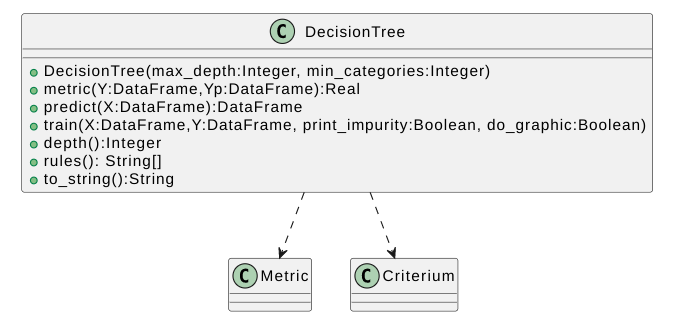

In [38]:
class DecisionTree:
  """ Representa un árbol de decisión
  """
  
  class Node:
    """ Clase interna que representa un nodo del árbol """
    def __init__(self, feature=None, value=None, prediction=None, left=None, right=None, depth=0):
      self.feature = feature        
      self.value = value            
      self.prediction = prediction  
      self.left = left              
      self.right = right            
      self.depth = depth            
      self.is_leaf = prediction is not None
  
  def __init__(self, max_depth: int, min_categories: int):
    """ inicializar la clase de árbol de decisión.
    Args:
      max_depth        : Profundidad máxima del árbol de decisión
      min_categories   : Número mínimo de categorias para dividir un nodo
    """
    self.max_depth = max_depth
    self.min_categories = min_categories
    self.root = None
    self.criterion = Criterium.use('Entropy')
    self.impurity_history = []

  def metric(self, Y: pd.DataFrame, Yp: pd.DataFrame) -> float:
    """ computa la metrica del modelo a partir de los ejemplares comparando las salidas
    Args:
      Y  : valores de salidas esperadas (etiquetadas)
      Yp : valores de salidas obtenidas
    Return:
       desempeño del modelo para ejemplares
    """
    accuracy_metric = Metric.use('Accuracy')
    return accuracy_metric.value(Y, Yp)

  def predict(self, X: pd.DataFrame) -> pd.DataFrame:
    """ computa una serie de entradas a traves del arbol generando una predicción
    Args:
      X    : valores de características (entradas)
    Return:
     valores de salidas obtenidas
    """
    if self.root is None:
      raise ValueError("El árbol no ha sido entrenado")
    
    predictions = []
    for _, row in X.iterrows():
      predictions.append(self._predict_one(self.root, row))
    
    return pd.DataFrame(predictions, columns=['prediction'])
  
  def _predict_one(self, node, row):
    """ Predice una instancia recorriendo el árbol """
    if node.is_leaf:
      return node.prediction
    
    if row[node.feature] == node.value:
      return self._predict_one(node.left, row)
    else:
      return self._predict_one(node.right, row)

  def train(self, X: pd.DataFrame, Y: pd.DataFrame, print_impurity: bool, do_graphic: bool):
    """ construye y entrena el árbol de decisión a partir de unos ejemplares.
    Args:
      X              : valores de características - conjunto de entrenamiento
      Y              : valores de salidas esperadas - conjunto de entrenamiento
      print_impurity : mostrar la impureza del arbol por iteración
      do_graphic     : graficar las impurezas por iteración
    """
    self.impurity_history = []
    data = pd.concat([X, Y], axis=1)
    self.root = self._build_tree(data, Y.columns[0], 0)
    
    if print_impurity:
      print("✓ Histórico de impurezas por iteración:")
      for i, imp in enumerate(self.impurity_history):
        print(f"  Iteración {i+1}: {imp:.4f}")
    
    if do_graphic:
      import matplotlib.pyplot as plt
      plt.figure(figsize=(10, 6))
      plt.plot(range(1, len(self.impurity_history)+1), self.impurity_history, marker='o')
      plt.xlabel('Iteración')
      plt.ylabel('Impureza del árbol')
      plt.title('Evolución de la impureza durante el entrenamiento')
      plt.grid(True)
      plt.show()
  
  def _build_tree(self, data: pd.DataFrame, target_col: str, current_depth: int):
    """ Construye el árbol recursivamente usando ganancia de información (ID3) """
    import math

    Y = data[target_col]
    unique_classes = Y.unique()
    

    if len(unique_classes) == 1 or current_depth >= self.max_depth:
      leaf_impurity = self.criterion.impurity(Y)
      self.impurity_history.append(leaf_impurity)
      return self.Node(prediction=unique_classes[0], depth=current_depth)
    

    if len(Y) < self.min_categories:
      prediction = Y.mode()[0]
      leaf_impurity = self.criterion.impurity(Y)
      self.impurity_history.append(leaf_impurity)
      return self.Node(prediction=prediction, depth=current_depth)
    

    features = [col for col in data.columns if col != target_col]
    X_only = data[features]
    best_feature = None
    best_gain = -math.inf
    best_value = None
    
    for feature in features:

      gain = self.criterion.gain(feature, X_only, Y)
      
      if gain > best_gain:

        for value in data[feature].unique():
          mask = data[feature] == value
          if 0 < mask.sum() < len(data):
            best_gain = gain
            best_feature = feature
            best_value = value
            break
    

    if best_feature is None:
      prediction = Y.mode()[0]
      leaf_impurity = self.criterion.impurity(Y)
      self.impurity_history.append(leaf_impurity)
      return self.Node(prediction=prediction, depth=current_depth)
    

    mask = data[best_feature] == best_value
    left_data = data[mask]
    right_data = data[~mask]
    
    left_node = self._build_tree(left_data, target_col, current_depth + 1)
    right_node = self._build_tree(right_data, target_col, current_depth + 1)
    
    return self.Node(
      feature=best_feature,
      value=best_value,
      left=left_node,
      right=right_node,
      depth=current_depth
    )

  def depth(self) -> int:
    """ consulta la profundidad del árbol
    Return:
      profundidad del árbol
    """
    if self.root is None:
      return 0
    return self._compute_depth(self.root)
  
  def _compute_depth(self, node):
    """ Calcula la profundidad máxima recursivamente """
    if node.is_leaf:
      return node.depth
    
    left_depth = self._compute_depth(node.left)
    right_depth = self._compute_depth(node.right)
    
    return max(left_depth, right_depth)

  def rules(self) -> [str]:
    """ consultar las reglas del árbol
    Return:
      reglas del árbol de decisión
    """
    if self.root is None:
      return []
    
    rules_list = []
    self._extract_rules(self.root, [], rules_list)
    return rules_list
  
  def _extract_rules(self, node, conditions, rules_list):
    """ Extrae las reglas del árbol recursivamente """
    if node.is_leaf:
      rule = " AND ".join(conditions) + f" => {node.prediction}"
      rules_list.append(rule)
      return
    
    left_conditions = conditions + [f"{node.feature} == {node.value}"]
    self._extract_rules(node.left, left_conditions, rules_list)
    
    right_conditions = conditions + [f"{node.feature} != {node.value}"]
    self._extract_rules(node.right, right_conditions, rules_list)

  def to_string(self) -> str:
    """ consultar la estructura del arbol
    Return:
      estructura del árbol
    """
    if self.root is None:
      return "Árbol vacío"
    
    lines = []
    self._build_string(self.root, "", True, lines)
    return "\n".join(lines)
  
  def _build_string(self, node, prefix, is_tail, lines):
    """ Construye representación en string del árbol """
    if node.is_leaf:
      lines.append(prefix + ("└── " if is_tail else "├── ") + f"LEAF: {node.prediction}")
    else:
      lines.append(prefix + ("└── " if is_tail else "├── ") + f"{node.feature} == {node.value}?")
      
      new_prefix = prefix + ("    " if is_tail else "│   ")
      self._build_string(node.left, new_prefix, False, lines)
      self._build_string(node.right, new_prefix, True, lines)


In [18]:
# Como primer caso de prueba entrene un árbol para calcular el operador lógico and. Explique los resultados.

print("CASO DE PRUEBA 1: Operador lógico AND")
print("-" * 50)


X_and = pd.DataFrame({
  'A': [0, 0, 1, 1],
  'B': [0, 1, 0, 1]
})

Y_and = pd.DataFrame({
  'Output': [0, 0, 0, 1]
})

print("\nDataset AND:")
print(pd.concat([X_and, Y_and], axis=1))


tree_and = DecisionTree(max_depth=3, min_categories=1)
tree_and.train(X_and, Y_and, print_impurity=True, do_graphic=False)

print(f"\nProfundidad del árbol: {tree_and.depth()}")
print(f"\nNúmero de reglas: {len(tree_and.rules())}")

print("\nReglas del árbol:")
for i, rule in enumerate(tree_and.rules(), 1):
  print(f"  {i}. {rule}")

print("\nEstructura del árbol:")
print(tree_and.to_string())


Y_pred_and = tree_and.predict(X_and)

print("\nPredicciones:")
results = pd.concat([X_and, Y_and, Y_pred_and], axis=1)
results.columns = ['A', 'B', 'Esperado', 'Predicción']
print(results)


accuracy_and = tree_and.metric(Y_and, Y_pred_and)
print(f"\nAccuracy: {accuracy_and:.4f}")

print("\nANÁLISIS:")
print("El árbol aprende perfectamente el operador AND, ya que:")
print("- Solo cuando ambos valores (A y B) son 1, la salida es 1")
print("- El árbol necesita verificar ambas condiciones")
print("- La impureza inicial es alta y disminuye a medida que el árbol se divide")

CASO DE PRUEBA 1: Operador lógico AND
--------------------------------------------------

Dataset AND:
   A  B  Output
0  0  0       0
1  0  1       0
2  1  0       0
3  1  1       1
✓ Histórico de impurezas por iteración:
  Iteración 1: -0.0000
  Iteración 2: -0.0000
  Iteración 3: -0.0000

Profundidad del árbol: 2

Número de reglas: 3

Reglas del árbol:
  1. A == 0 => 0
  2. A != 0 AND B == 0 => 0
  3. A != 0 AND B != 0 => 1

Estructura del árbol:
└── A == 0?
    ├── LEAF: 0
    └── B == 0?
        ├── LEAF: 0
        └── LEAF: 1

Predicciones:
   A  B  Esperado  Predicción
0  0  0         0           0
1  0  1         0           0
2  1  0         0           0
3  1  1         1           1

Accuracy: 1.0000

ANÁLISIS:
El árbol aprende perfectamente el operador AND, ya que:
- Solo cuando ambos valores (A y B) son 1, la salida es 1
- El árbol necesita verificar ambas condiciones
- La impureza inicial es alta y disminuye a medida que el árbol se divide


In [24]:
# Como segundo caso de prueba entrene un árbol para calcular el operador lógico or. Explique los resultados.

print("CASO DE PRUEBA 2: Operador lógico OR")
print("-" * 50)


X_or = pd.DataFrame({
  'A': [0, 0, 1, 1],
  'B': [0, 1, 0, 1]
})

Y_or = pd.DataFrame({
  'Output': [0, 1, 1, 1]
})

print("\nDataset OR:")
print(pd.concat([X_or, Y_or], axis=1))


tree_or = DecisionTree(max_depth=3, min_categories=1)
tree_or.train(X_or, Y_or, print_impurity=True, do_graphic=False)

print(f"\nProfundidad del árbol: {tree_or.depth()}")
print(f"\nNúmero de reglas: {len(tree_or.rules())}")

print("\nReglas del árbol:")
for i, rule in enumerate(tree_or.rules(), 1):
  print(f"  {i}. {rule}")

print("\nEstructura del árbol:")
print(tree_or.to_string())


Y_pred_or = tree_or.predict(X_or)

print("\nPredicciones:")
results = pd.concat([X_or, Y_or, Y_pred_or], axis=1)
results.columns = ['A', 'B', 'Esperado', 'Predicción']
print(results)


accuracy_or = tree_or.metric(Y_or, Y_pred_or)
print(f"\nAccuracy: {accuracy_or:.4f}")

print("\n💡 ANÁLISIS:")
print("El árbol aprende perfectamente el operador OR, ya que:")
print("- Si cualquiera de los valores (A o B) es 1, la salida es 1")
print("- Solo cuando ambos son 0, la salida es 0")
print("- El árbol puede dividir eficientemente con una o dos condiciones")

CASO DE PRUEBA 2: Operador lógico OR
--------------------------------------------------

Dataset OR:
   A  B  Output
0  0  0       0
1  0  1       1
2  1  0       1
3  1  1       1
✓ Histórico de impurezas por iteración:
  Iteración 1: -0.0000
  Iteración 2: -0.0000
  Iteración 3: -0.0000

Profundidad del árbol: 2

Número de reglas: 3

Reglas del árbol:
  1. A == 0 AND B == 0 => 0
  2. A == 0 AND B != 0 => 1
  3. A != 0 => 1

Estructura del árbol:
└── A == 0?
    ├── B == 0?
    │   ├── LEAF: 0
    │   └── LEAF: 1
    └── LEAF: 1

Predicciones:
   A  B  Esperado  Predicción
0  0  0         0           0
1  0  1         1           1
2  1  0         1           1
3  1  1         1           1

Accuracy: 1.0000

💡 ANÁLISIS:
El árbol aprende perfectamente el operador OR, ya que:
- Si cualquiera de los valores (A o B) es 1, la salida es 1
- Solo cuando ambos son 0, la salida es 0
- El árbol puede dividir eficientemente con una o dos condiciones


In [26]:
# Como tercer caso de prueba entrene un árbol para calcular el operador lógico xor. Explique los resultados.


print("CASO DE PRUEBA 3: Operador lógico XOR")
print("-" * 50)


X_xor = pd.DataFrame({
  'A': [0, 0, 1, 1],
  'B': [0, 1, 0, 1]
})

Y_xor = pd.DataFrame({
  'Output': [0, 1, 1, 0]
})

print("\nDataset XOR:")
print(pd.concat([X_xor, Y_xor], axis=1))


tree_xor = DecisionTree(max_depth=3, min_categories=1)
tree_xor.train(X_xor, Y_xor, print_impurity=True, do_graphic=False)

print(f"\nrofundidad del árbol: {tree_xor.depth()}")
print(f"\nNúmero de reglas: {len(tree_xor.rules())}")

print("\nReglas del árbol:")
for i, rule in enumerate(tree_xor.rules(), 1):
  print(f"  {i}. {rule}")

print("\nEstructura del árbol:")
print(tree_xor.to_string())


Y_pred_xor = tree_xor.predict(X_xor)

print("\nPredicciones:")
results = pd.concat([X_xor, Y_xor, Y_pred_xor], axis=1)
results.columns = ['A', 'B', 'Esperado', 'Predicción']
print(results)


accuracy_xor = tree_xor.metric(Y_xor, Y_pred_xor)
print(f"\nAccuracy: {accuracy_xor:.4f}")

print("\nANÁLISIS:")
print("El árbol aprende perfectamente el operador XOR, aunque es más complejo:")
print("- XOR es 1 solo cuando los valores son diferentes (0,1 o 1,0)")
print("- XOR es 0 cuando los valores son iguales (0,0 o 1,1)")
print("- El árbol necesita mayor profundidad para capturar esta lógica no lineal")
print("- Los árboles de decisión pueden resolver XOR, a diferencia de perceptrones simples")

CASO DE PRUEBA 3: Operador lógico XOR
--------------------------------------------------

Dataset XOR:
   A  B  Output
0  0  0       0
1  0  1       1
2  1  0       1
3  1  1       0
✓ Histórico de impurezas por iteración:
  Iteración 1: -0.0000
  Iteración 2: -0.0000
  Iteración 3: -0.0000
  Iteración 4: -0.0000

rofundidad del árbol: 2

Número de reglas: 4

Reglas del árbol:
  1. A == 0 AND B == 0 => 0
  2. A == 0 AND B != 0 => 1
  3. A != 0 AND B == 0 => 1
  4. A != 0 AND B != 0 => 0

Estructura del árbol:
└── A == 0?
    ├── B == 0?
    │   ├── LEAF: 0
    │   └── LEAF: 1
    └── B == 0?
        ├── LEAF: 1
        └── LEAF: 0

Predicciones:
   A  B  Esperado  Predicción
0  0  0         0           0
1  0  1         1           1
2  1  0         1           1
3  1  1         0           0

Accuracy: 1.0000

ANÁLISIS:
El árbol aprende perfectamente el operador XOR, aunque es más complejo:
- XOR es 1 solo cuando los valores son diferentes (0,1 o 1,0)
- XOR es 0 cuando los valores son

CASO DE PRUEBA 4: Dataset NPHA doctor visits
--------------------------------------------------

Información del dataset:
  - Dimensiones: (714, 15)
  - Características: 14
  - Ejemplares: 714

Primeras filas:
   Number of Doctors Visited  Age  Phyiscal Health  Mental Health  \
0                          3    2                4              3   
1                          2    2                4              2   
2                          3    2                3              2   
3                          1    2                3              2   
4                          3    2                3              3   

   Dental Health  Employment  Stress Keeps Patient from Sleeping  \
0              3           3                                   0   
1              3           3                                   1   
2              3           3                                   0   
3              3           3                                   0   
4              3           3       

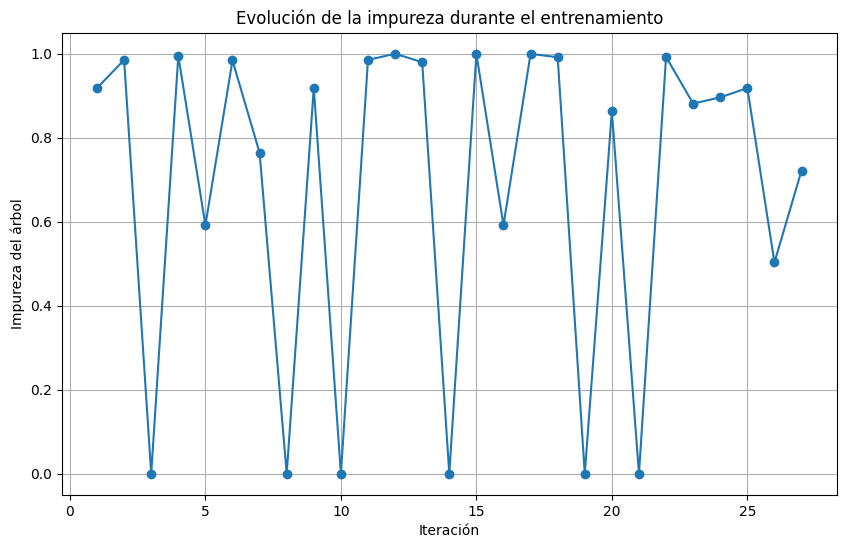


Profundidad del árbol: 5

Número de reglas: 27

Primeras 10 reglas del árbol:
  1. Phyiscal Health == 3 AND Employment == 3 AND Trouble Sleeping == 1 AND Bathroom Needs Keeps Patient from Sleeping == 0 AND Mental Health == 2 => 2
  2. Phyiscal Health == 3 AND Employment == 3 AND Trouble Sleeping == 1 AND Bathroom Needs Keeps Patient from Sleeping == 0 AND Mental Health != 2 => 1
  3. Phyiscal Health == 3 AND Employment == 3 AND Trouble Sleeping == 1 AND Bathroom Needs Keeps Patient from Sleeping != 0 => 2
  4. Phyiscal Health == 3 AND Employment == 3 AND Trouble Sleeping != 1 AND Mental Health == 3 AND Stress Keeps Patient from Sleeping == 0 => 1
  5. Phyiscal Health == 3 AND Employment == 3 AND Trouble Sleeping != 1 AND Mental Health == 3 AND Stress Keeps Patient from Sleeping != 0 => 1
  6. Phyiscal Health == 3 AND Employment == 3 AND Trouble Sleeping != 1 AND Mental Health != 3 AND Prescription Sleep Medication == 3 => 2
  7. Phyiscal Health == 3 AND Employment == 3 AND Trouble Sle

In [28]:
# Como último caso de prueba entrene un árbol para el dataset propuesto por su profesor. Use 80% para entrenamiento y 20% para pruebas. Explique los resultado.


print("CASO DE PRUEBA 4: Dataset NPHA doctor visits")
print("-" * 50)


dataset = pd.read_csv('NPHA-doctor-visits.csv')

print("\nInformación del dataset:")
print(f"  - Dimensiones: {dataset.shape}")
print(f"  - Características: {dataset.shape[1] - 1}")
print(f"  - Ejemplares: {dataset.shape[0]}")

print("\nPrimeras filas:")
print(dataset.head())

print("\nInformación estadística:")
print(dataset.describe())


target_col = dataset.columns[-1]
feature_cols = [col for col in dataset.columns if col != target_col]

X = dataset[feature_cols]
Y = dataset[[target_col]]

print(f"\nVariable objetivo: {target_col}")
print(f"Características: {', '.join(feature_cols)}")


print(f"\nDistribución de clases:")
print(Y[target_col].value_counts())


from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

print(f"\nDivisión de datos:")
print(f"  - Entrenamiento: {len(X_train)} ejemplares ({len(X_train)/len(X)*100:.1f}%)")
print(f"  - Pruebas: {len(X_test)} ejemplares ({len(X_test)/len(X)*100:.1f}%)")


print("\nEntrenando árbol de decisión...")
tree_dataset = DecisionTree(max_depth=5, min_categories=2)
tree_dataset.train(X_train, Y_train, print_impurity=True, do_graphic=True)

print(f"\nProfundidad del árbol: {tree_dataset.depth()}")
print(f"\nNúmero de reglas: {len(tree_dataset.rules())}")

print("\nPrimeras 10 reglas del árbol:")
for i, rule in enumerate(tree_dataset.rules()[:10], 1):
  print(f"  {i}. {rule}")
if len(tree_dataset.rules()) > 10:
  print(f"  ... y {len(tree_dataset.rules()) - 10} reglas más")


Y_pred_train = tree_dataset.predict(X_train)
accuracy_train = tree_dataset.metric(Y_train, Y_pred_train)


Y_pred_test = tree_dataset.predict(X_test)
accuracy_test = tree_dataset.metric(Y_test, Y_pred_test)

print(f"\nRESULTADOS:")
print(f"  Accuracy - Entrenamiento: {accuracy_train:.4f}")
print(f"  Accuracy - Pruebas: {accuracy_test:.4f}")


diff = abs(accuracy_train - accuracy_test)
print(f"\nDiferencia Train-Test: {diff:.4f}")

print("\nANÁLISIS:")
if accuracy_train > 0.95 and accuracy_test > 0.90:
  print("El modelo tiene excelente desempeño en ambos conjuntos")
  print("   - Bajo sesgo y baja varianza (modelo óptimo)")
elif accuracy_train > 0.90 and diff < 0.10:
  print("El modelo generaliza bien")
  print("   - Sesgo razonable y varianza controlada")
elif diff > 0.15:
  print("Posible sobreajuste (overfitting)")
  print("   - Bajo sesgo pero alta varianza")
  print("   - Considere reducir max_depth o aumentar min_categories")
elif accuracy_train < 0.75:
  print("Posible subajuste (underfitting)")
  print("   - Alto sesgo")
  print("   - Considere aumentar max_depth o reducir min_categories")
else:
  print("El modelo tiene un desempeño balanceado")

print("\nObservaciones adicionales:")
print(f"  - El árbol tiene {tree_dataset.depth()} niveles de profundidad")
print(f"  - Se generaron {len(tree_dataset.rules())} reglas de decisión")
print(f"  - La impureza del árbol disminuyó durante el entrenamiento")

# **PARTE II. USO DE FRAMEWORK PARA ARBOLES DE DECISIÓN**

Para este apartado se va a hacer uso de una librería que brinda de manera simplificada un entrenamiento flexible de distintos algoritmos basados en árboles de deciisón. En este caso será **scikit-learn**

**scikit-learn** es una biblioteca de Python que facilita la implementación de algoritmos de aprendizaje automático. Es ampliamente usada en la industria por su simplicidad, buena documentación y eficiencia.

**scikit-learn** ofrece diferentes estrategias de aprendizaje basadas en árboles; entre ellas las que exploraremos en este laboratorio.
- [DecisionTreeClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html)
- [RandomForestClassifier](https://scikit-learn.org/stable/search.html?q=RandomForestClassifier)
- [GradientBoostingClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingClassifier.html)

---
Resuelvan un problema de clasificación usando el *dataset* definido por su profesor. (70% entrenamiento, 10% validación y 20% pruebas)

##Paso 1: Definir el problema
Antes de desarrollar un modelo, es fundamental establecer qué se quiere lograr y cómo se medirá el éxito. Esto implica explicar el problema, elegir una métrica adecuada (f1_score) y establecer un umbral de desempeño.


*Incluyan la respuesta*

##Paso 2: Explorar y preparar los datos
Para comprender la naturaleza de los datos que estamos utilizando es necesario **explorar** el *dataset* con visualizaciones adecuadas que permitan conocer la distribución de clases o valores, la presencia de valores nulos o atípicos y las correlaciones entre variables.

**Preparar** los datos para que la red pueda aprender de manera eficiente implica, cuando se requiera, la limpieza de datos, la normalización o estandarización de valores, la codificación de variables categóricas y la separación en conjuntos de entrenamiento (train), validación (dev) y prueba (test).

In [16]:
#Analizar los datos

*Incluyan observaciones*

In [17]:
#Preparar los datos separandolos en entrenamiento, validación y pruebas.

##Paso 3: Desarrollar el modelo
La estrategia que vamos a seguir es desarrollar tres modelos diferentes y escoger entre ellos el mejor modelo para probarlo.
- Los tres modelos se entrenan con *train*
- El mejor modelo se selecciona con *dev*
- El modelo seleccionado se prueba con *test*

###Paso 3.1: Entrenar los modelos candidatos

#### Paso 3.1.1: Entrenar un árbol de decisión

1. Se crea una instancia de la clase `DecisionTreeClassifier`
2. Se entrena (`.fit(X,y)`)
3. Se consulta la métrica f1 (`.predict(X)` y `f1_score(Y, Y_p)`)


In [18]:
# Entrenar un árbol de decisión

#### Paso 3.1.2: Entrenar un bosque aleatorio

1. Se crea una instancia de la clase `RandomForestClassifier`
2. Se entrena (`.fit(X,y)`)
3. Se consulta la métrica f1 (`.predict(X)` y `f1_score(Y, Y_p)`)

In [19]:
#Entrenar un bosque aleatorio

#### Paso 3.1.3: Entrenar un bosque con potenciación de gradiente
1. Se crea una instancia de la clase `GradientBoostingClassifier`
2. Se entrena (`.fit(X,y)`)
3. Se consulta la métrica f1 (`.predict(X)` y `f1_score(Y, Y_p)`)

In [20]:
#Entrenar el bosque con potenciación de gradiente

### Paso 3.2: Seleccionar el mejor modelo

Para seleccionar el modelo se usa el conjunto de datos de validación.

1. Se consulta la métrica f1 de cada uno de los modelos (.predict(X) y f1_score(Y, Y_p))

###Paso 3.3: Probar el modelo seleccionado
Ya seleccionado el modelo con el conjunto de datos de validación, se puede probar su rendimiento con los datos de prueba.
1. Se consulta la métrica f1 del modelo (.predict(X) y f1_score(Y, Y_p))

In [21]:
#Evaluar el modelo

##Paso 4: Redactar conclusiones

*Incluyan las conclusiones*
- Comparen los resultados de entrenamiento de los tres modelos incluyendo datos como: altura, impureza, exactitud y número de reglas. Presenten tabla y expliquen los datos. Indiquen el modelo que escogerían en este punto del proceso justificando la respuesta.
- Comparen los resultados de validación de los tres modelos incluyendo:
exactitud en entrenamiento y exactitud en validación. Expliquen en terminos de sesgo y varianza.
- Presenten los resultados logrados con el modelo seleccionado. Enumeren los hallazgos.

## RETROSPECTIVA

**1.** ¿Cuál fue el tiempo total invertido en el laboratorio por cada uno de ustedes? (Horas/Hombre)

**2.** ¿Cuál es el estado actual del laboratorio? ¿Por qué?

**3.** ¿Cuál consideran fue el mayor logro? ¿Por qué?

**4.** ¿Cuál consideran que fue el mayor problema técnico? ¿Qué hicieron para resolverlo?

**5.** ¿Qué hicieron bien como equipo? ¿Qué se comprometen a hacer para mejorar los resultados?

**6**.¿Qué referencias usaron? ¿Cuál fue la más útil? Incluya citas con los estándares adecuados.

*Incluyan las respuesta*